In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

## (a) Generate Undirected PA Network

Connected: True | Nodes: 900 | Edges: 899 | Mean degree: 1.998


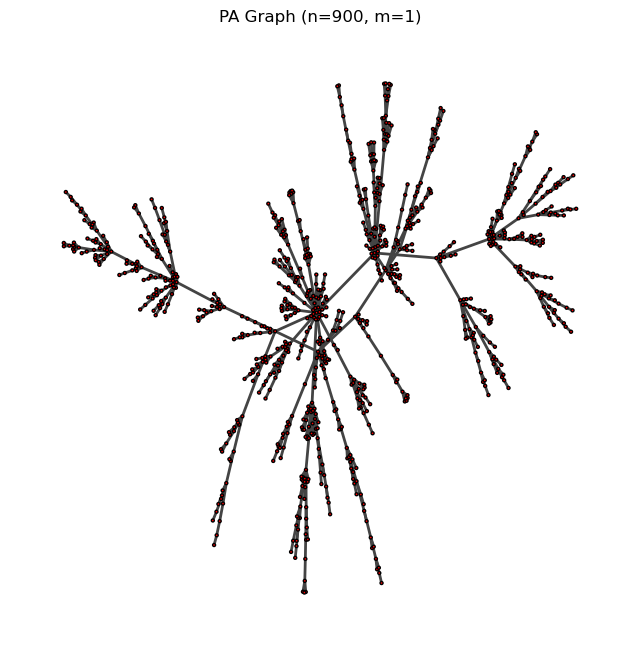

In [2]:
np.random.seed(0)

g = ig.Graph.Barabasi(n=900, m=1, directed=False)
fig, ax = plt.subplots(figsize=(8, 8))
ig.plot(g, target=ax, vertex_size=3, vertex_label=None)
ax.set_title("PA Graph (n=900, m=1)")

print(f"Connected: {g.is_connected()} | Nodes: {g.vcount()} | Edges: {g.ecount()} | Mean degree: {np.mean(g.degree()):.3f}")

## (b) Measure $\langle s(t)\rangle$ v.s. $t$ and $\sigma^2(t)$ v.s. $t$

In [3]:
def create_transition_matrix(g):
    adj = np.array(g.get_adjacency().data, dtype=float)
    row_sums = adj.sum(axis=1)

    isolated = np.where(row_sums == 0)[0]
    adj[isolated, isolated] = 1.0
    row_sums = adj.sum(axis=1)
    return adj / row_sums[:, np.newaxis]

In [5]:
def random_walk(g, num_steps, start_node, transition_matrix=None, 
               teleport_prob=0.0, teleport_weights=None, track_path=False):
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)
    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None
    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)
            
    if track_path:
        return path
    return v

In [7]:
def measure_s_t(graph, num_steps=100, num_runs=1000):
    transition_matrix = create_transition_matrix(graph)
    n = graph.vcount()

    all_s = np.zeros((num_runs, num_steps+1))

    for r in range(num_runs):
        start_node = np.random.randint(n)
        path = random_walk(graph, num_steps=num_steps, start_node=start_node,
                           transition_matrix = transition_matrix, track_path=True)
        dist_from_start = np.array(graph.distances(source=[start_node])[0])
        all_s[r] = dist_from_start[path]

    mean_s = all_s.mean(axis=0)
    var_s = all_s.var(axis=0)
    return mean_s, var_s

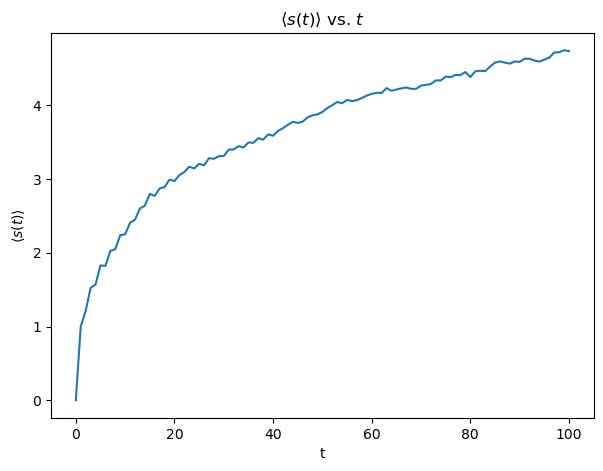

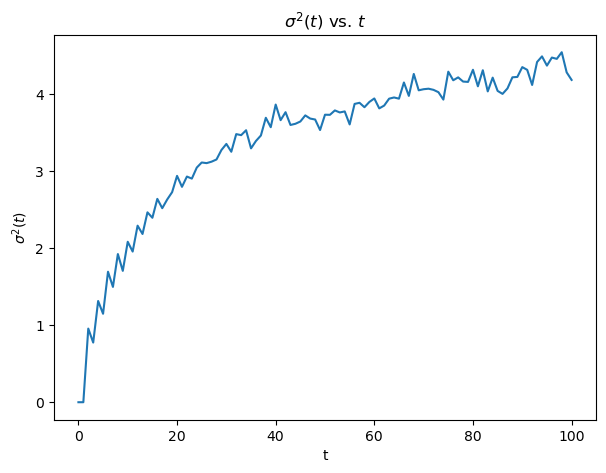

In [9]:
num_steps = 100
num_runs = 1000
mean_s, var_s = measure_s_t(g)
t = np.arange(num_steps+1)

plt.figure(figsize=(7,5))
plt.plot(t, mean_s)
plt.xlabel("t")
plt.ylabel(r"$\langle s(t) \rangle$")
plt.title(r"$\langle s(t) \rangle$ vs. $t$")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(t, var_s)
plt.xlabel("t")
plt.ylabel(r"$\sigma^2(t)$")
plt.title(r"$\sigma^2(t)$ vs. $t$")
plt.show()


## (c) Degree Distribution
The endpoint degree distribution is biased toward nodes with higheer degrees than the graph's degree distribution. The average endpoint degree (4.451) is much larger than the graph’s average degree (1.998). This happens because random walks are more likely to end at high-degree nodes.

In [15]:
def degree_distribution(degrees):
    counts = Counter(degrees)
    k_vals = np.array(sorted(counts.keys()))
    freq = np.array([counts[k] / len(degrees) for k in k_vals])
    return k_vals, freq

def endpoint_degree_distribution(graph, num_steps, num_runs):
    transition_matrix = create_transition_matrix(graph)
    n = graph.vcount()
    endpoint_degrees = []

    for _ in range(num_runs):
        start_node = np.random.randint(n)
        end_node = random_walk(graph, num_steps, start_node, transition_matrix)
        endpoint_degrees.append(graph.degree(end_node))
    return np.array(endpoint_degrees)

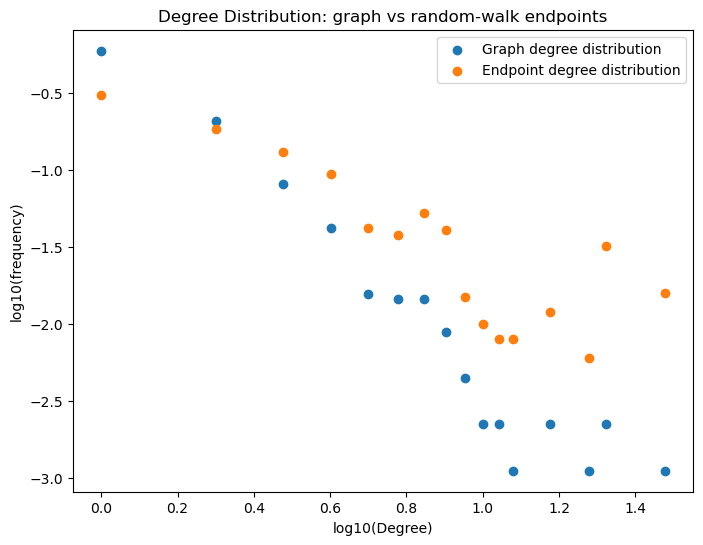

Average degree of graph nodes: 1.998
Average degree of endpoint nodes: 4.451


In [16]:
graph_deg = np.array(g.degree())
k_graph, f_graph = degree_distribution(graph_deg)

endpoint_deg = endpoint_degree_distribution(g, num_steps, num_runs)
k_end, f_end = degree_distribution(endpoint_deg)

mask_graph = k_graph > 0
mask_end = k_end > 0

log_k_graph = np.log10(k_graph[mask_graph])
log_f_graph = np.log10(f_graph[mask_graph])
log_k_end = np.log10(k_end[mask_end])
log_f_end = np.log10(f_end[mask_end])

plt.figure(figsize=(8, 6))
plt.scatter(log_k_graph, log_f_graph, label="Graph degree distribution")
plt.scatter(log_k_end, log_f_end, label="Endpoint degree distribution")
plt.xlabel("log10(Degree)")
plt.ylabel("log10(frequency)")
plt.title("Degree Distribution: graph vs random-walk endpoints")
plt.legend()
plt.show()

print(f"Average degree of graph nodes: {np.mean(graph_deg):.3f}")
print(f"Average degree of endpoint nodes: {np.mean(endpoint_deg):.3f}")


## (d) Try PA Networks with Different # of Nodes
The larger PA network shows larger values of both $\langle s(t)\rangle$ and 
$\sigma^2(t)$ which indicates that the random walker can move farther away from the starting node and have larger variation in distance in larger networks. The diameter plays an important role because a network with larger diameter has larger longest shortest path between nodes which allows the walker has more room to move farther away from the starting node.

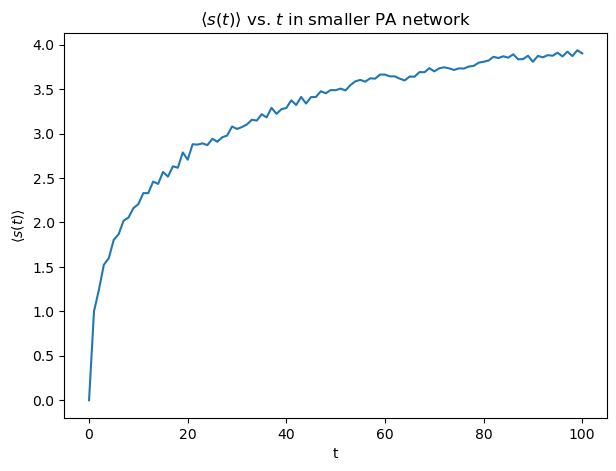

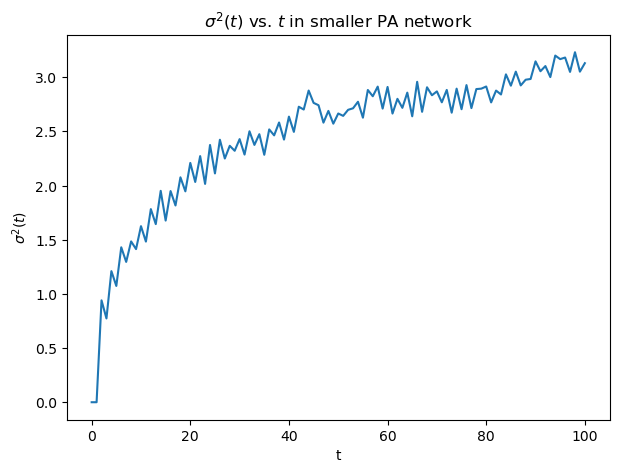

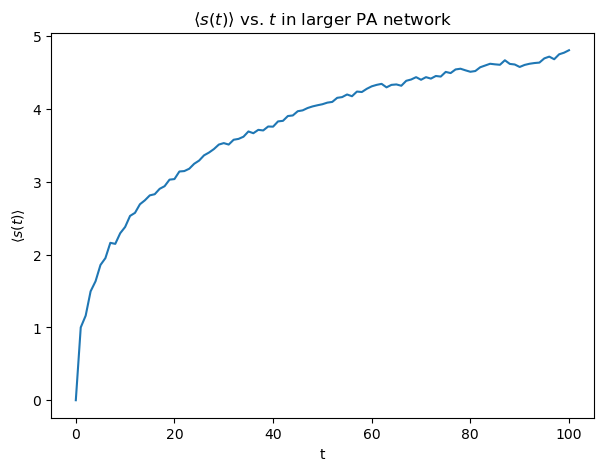

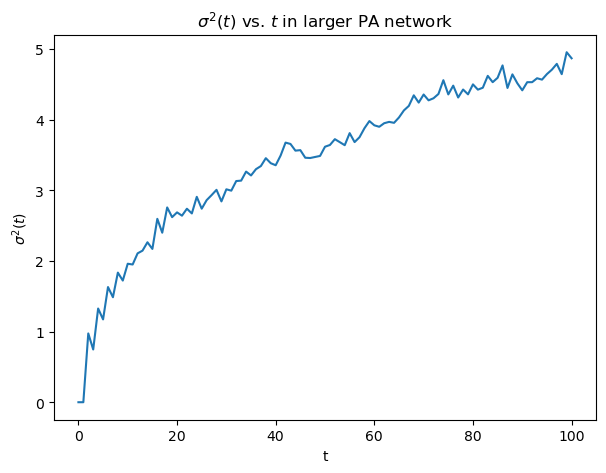

In [18]:
#n=90 nodes
g_smaller = ig.Graph.Barabasi(n=90, m=1, directed=False)
mean_s_smaller, var_s_smaller = measure_s_t(g_smaller)
t = np.arange(num_steps+1)

plt.figure(figsize=(7,5))
plt.plot(t, mean_s_smaller)
plt.xlabel("t")
plt.ylabel(r"$\langle s(t) \rangle$")
plt.title(r"$\langle s(t) \rangle$ vs. $t$ in smaller PA network")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(t, var_s_smaller)
plt.xlabel("t")
plt.ylabel(r"$\sigma^2(t)$")
plt.title(r"$\sigma^2(t)$ vs. $t$ in smaller PA network")
plt.show()

#9000 nodes
g_larger = ig.Graph.Barabasi(n=9000, m=1, directed=False)
mean_s_larger, var_s_larger = measure_s_t(g_larger)

plt.figure(figsize=(7, 5))
plt.plot(t, mean_s_larger)
plt.xlabel("t")
plt.ylabel(r"$\langle s(t)\rangle$")
plt.title(R"$\langle s(t)\rangle$ vs. $t$ in larger PA network")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(t, var_s_larger)
plt.xlabel("t")
plt.ylabel(r"$\sigma^2(t)$")
plt.title(r"$\sigma^2(t)$ vs. $t$ in larger PA network")
plt.show()

In [19]:
print(f"Diameter of graph with 900 nodes: {g.diameter()}")
print(f"Diameter of graph with 90 nodes: {g_smaller.diameter()}")
print(f"Diameter of graph with 9000 nodes: {g_larger.diameter()}")

Diameter of graph with 900 nodes: 19
Diameter of graph with 90 nodes: 10
Diameter of graph with 9000 nodes: 29
